## Load Measurement Data

In [4]:
from pathlib import Path
import h5py
import polars as pl


# Point to the measurement directory
data_dir = Path("XiZhang_ACRPhantom_Tc99m_May16_Coordinate_MLEnearest")
h5_files = sorted(data_dir.glob("*.h5"))

print(f"Found {len(h5_files)} measurement files")


# Extract the head ID from the file name
head_ids = [int(path.stem.split("_M")[-1]) for path in h5_files]
print(f"Head IDs: {head_ids}")

Found 20 measurement files
Head IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [10]:

# Inspect one file first to confirm the dataset name and shape
sample_path = h5_files[0]
with h5py.File(sample_path, "r") as f:
    sample_key = list(f.keys())[0]
    sample_data = f[sample_key][:]
    print(f"Sample file: {sample_path.name}")
    print(f"Dataset name: {sample_key}")
    print(f"Shape: {sample_data.shape}")
    print("First 5 rows:\n", sample_data[:5])

# Load all files into one Polars DataFrame for easier inspection
frames = []
for path in h5_files:
    with h5py.File(path, "r") as f:
        arr = f[sample_key][:]
    frames.append(
        pl.DataFrame(
            {
                "head_id": int(path.stem.split("_M")[-1]),
                "energy": arr[:, 0],
                "x": arr[:, 1].astype(int),
                "y": arr[:, 2].astype(int),
            }
        )
    )

measurement_df = pl.concat(frames, how="vertical_relaxed")
print("\nCombined table shape:", measurement_df.shape)
measurement_df.head()


Sample file: Coordinate_MLEnearest_Data_05152026_141638_M1.h5
Dataset name: data_output
Shape: (53874, 3)
First 5 rows:
 [[3.47293422e+04 1.10000000e+01 2.30000000e+01]
 [3.11599017e+04 1.00000000e+01 1.30000000e+01]
 [3.34634716e+04 7.00000000e+00 2.20000000e+01]
 [2.97442864e+04 6.00000000e+00 2.30000000e+01]
 [3.12337837e+04 1.80000000e+01 2.30000000e+01]]

Combined table shape: (1737068, 4)


head_id,energy,x,y
i32,f64,i64,i64
1,34729.342222,11,23
1,31159.901728,10,13
1,33463.471605,7,22
1,29744.28642,6,23
1,31233.783704,18,23


In [6]:
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 0, 'Energy')

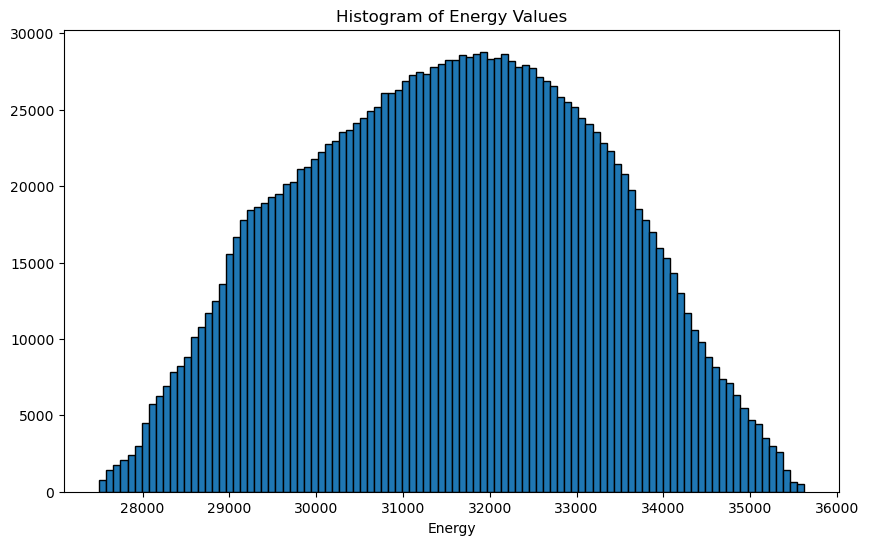

In [11]:
singles_energy = measurement_df.select("energy").to_numpy().flatten()
# plot the histogram of the energy values
energy_counts, energy_edges = np.histogram(singles_energy, bins=100)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(energy_edges[:-1], energy_counts, width=np.diff(energy_edges), edgecolor="black", align="edge")
ax.set_title("Histogram of Energy Values")
ax.set_xlabel("Energy")

In [13]:
# Print min and max of the x, y
x_min, x_max = measurement_df.select("x").to_numpy().min(), measurement_df.select("x").to_numpy().max()
y_min, y_max = measurement_df.select("y").to_numpy().min(), measurement_df.select("y").to_numpy().max()
print(f"x range: {x_min} to {x_max}, y range: {y_min} to {y_max}")

x range: 1 to 25, y range: 1 to 25


In [16]:
# Find the min and max of head_id
head_id_min, head_id_max = measurement_df.select("head_id").to_numpy().min(), measurement_df.select("head_id").to_numpy().max()
print(f"head_id range: {head_id_min} to {head_id_max}")

head_id range: 1 to 20


In [19]:
x_id = measurement_df.select("x").to_numpy().flatten() - 1
y_id = measurement_df.select("y").to_numpy().flatten() - 1
pixel_id = x_id *25 + y_id
head_id = measurement_df.select("head_id").to_numpy().flatten() + 39
linear_indices = head_id * 625 + pixel_id
# Count the number of events for each pixel and head_id
counts_1d = np.bincount(linear_indices, minlength=80 * 625)
counts_2d = counts_1d.reshape((80, 625))

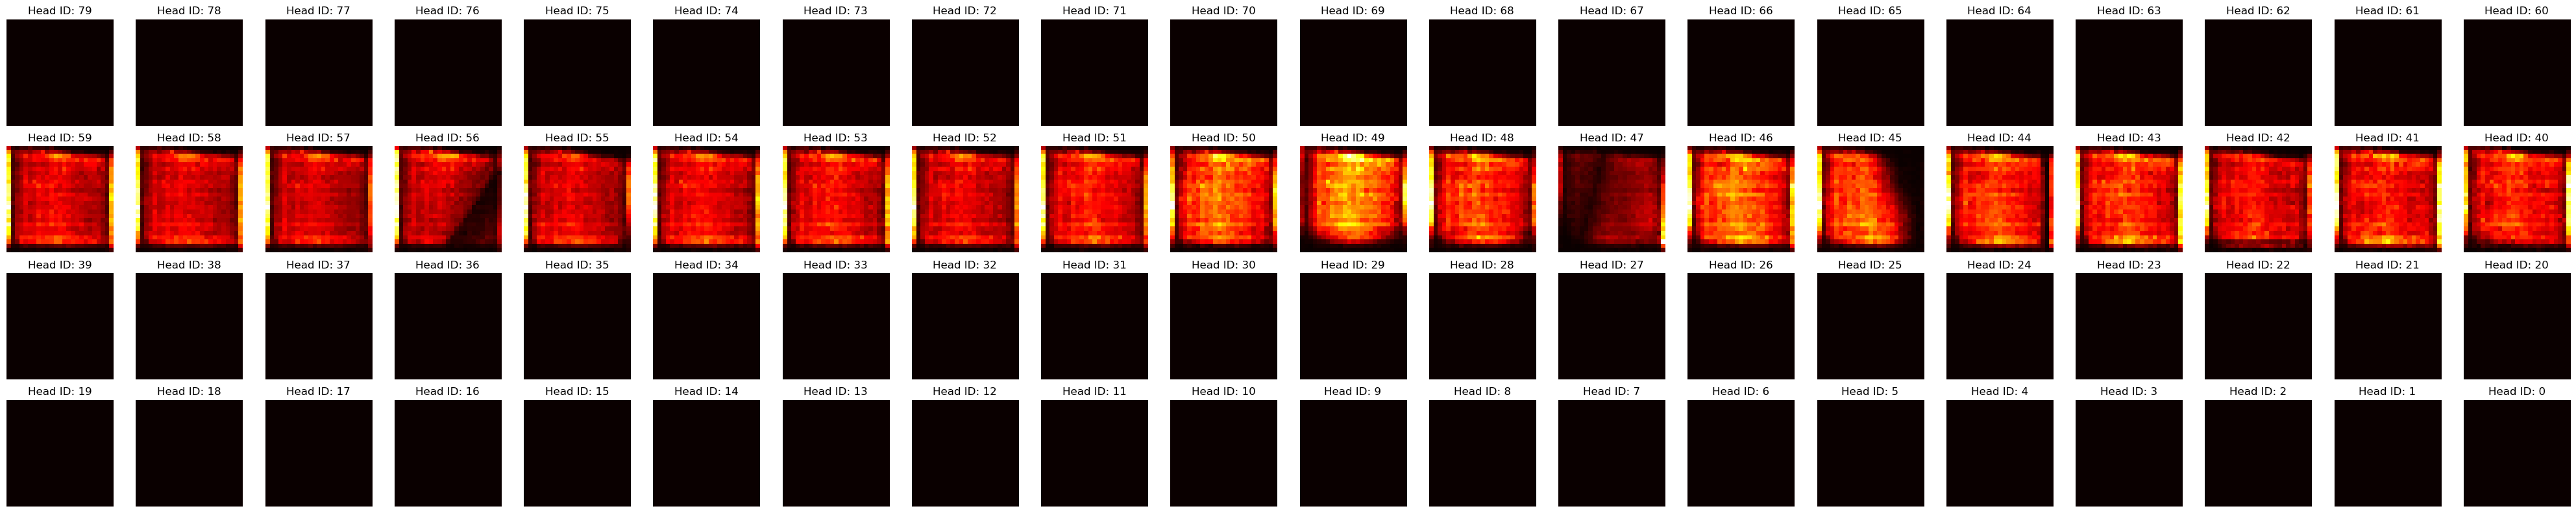

In [28]:
# Plot the counts for each head_id
fig, axes = plt.subplots(4, 20, figsize=(40, 8))
for i in np.arange(80):
    subplot_index = 79-i
    ax = axes[subplot_index // 20, subplot_index % 20]
    ax.imshow(counts_2d[i].reshape((25, 25)).T, cmap="hot", interpolation="nearest", origin="lower")
    ax.set_title(f"Head ID: {i}")
    ax.axis("off")
plt.tight_layout()


In [29]:
import sparse
ospool_sparse_srm_filename = "job_14965616_stacked_sparse_5d_srm.h5"
ospool_sparse_srm_dir = Path("../")
with h5py.File(ospool_sparse_srm_dir / ospool_sparse_srm_filename, "r") as f:
    ospool_sparse_srm = sparse.COO(
        f['srm/coords'][:], # type: ignore
        f['srm/data'][:], # type: ignore
        shape=tuple(f['srm'].attrs['shape']) # type: ignore
    )

In [30]:
from mlem_sparse.io import SparseSRM_IO_Manager, MeasurementMat_IO_Manager
from mlem_sparse.reconstruct import SparseMLEMReconstructor

import torch

# Load the system matrix
srm_io_mgr = SparseSRM_IO_Manager()
ospool_sparse_srm_reshaped = ospool_sparse_srm.reshape((80 * 625, 80 **3))
scipy_coo = ospool_sparse_srm_reshaped.to_scipy_sparse()
scipy_csr = scipy_coo.tocsr()
sparse_mlem_reconstructor_gpu = SparseMLEMReconstructor(
    scipy_csr,
    counts_1d,
    device=torch.device("cuda"),
)

/home/fanghan/Work/RPIL/QMIRT/mc-srm-recon/mlem_sparse/src/mlem_sparse/reconstruct/sparse_mlem_reconstructor.py:156: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  self.srm_csr_tensor = torch.sparse_csr_tensor(
/home/fanghan/Work/RPIL/QMIRT/mc-srm-recon/mlem_sparse/src/mlem_sparse/reconstruct/sparse_mlem_reconstructor.py:156: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.srm_csr_tensor = torch.sparse_csr_tensor(


Memory check passed!Transpose requires ~2.63 GB.
Available CUDA memory: 9.55 GB.
Computing explicit transpose matrix...


In [31]:
iters = [1, 3, 5, 10, 20, 30, 40, 50, 70, 100, 200]
estimate_vol_sparse_mlem_tensor_from_gpu = sparse_mlem_reconstructor_gpu.reconstruct(
    iterations=iters
)
estimate_data_np_from_gpu = np.array(
    [
        gpu_tensor.detach().cpu().numpy()
        for gpu_tensor in estimate_vol_sparse_mlem_tensor_from_gpu
    ]
)
del estimate_vol_sparse_mlem_tensor_from_gpu

MLEM Iteration:   0%|          | 0/200 [00:00<?, ?it/s]

In [33]:
output_dir = Path("reconstructed_images_acr_phantom_measurement_ospool_srm")/"lower_half"
output_dir.mkdir(exist_ok=True)

img_shape = (80, 80, 80)
fov_dim_mm = (160.0, 160.0, 160.0)
xy_extent = (
    -fov_dim_mm[0] * 0.5,
    fov_dim_mm[0] * 0.5,
    -fov_dim_mm[1] * 0.5,
    fov_dim_mm[1] * 0.5,
)

for iter_id in range(len(iters)):
    estimate_iter = estimate_data_np_from_gpu[iter_id]
    estimate_iter = estimate_iter.reshape(img_shape)
    img = estimate_iter[:, :, 10:40].sum(axis=2)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6),layout="constrained")
    im = ax.imshow(img.T, cmap="hot", origin="lower", extent=xy_extent, aspect="equal",interpolation="none")
    ax.set_title(
        f"Reconstructed Image, ACR Phantom Measurements, Iteration {iters[iter_id]}"
    )
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    plt.colorbar(im, ax=ax)
    fig.savefig(output_dir / f"reconstructed_image_acr_phantom_iter_{iters[iter_id]}.png", dpi=300)
    plt.close(fig)

In [34]:
scipy_coo = ospool_sparse_srm[40:60].reshape((20 * 625, 80**3)).to_scipy_sparse()
scipy_csr = scipy_coo.tocsr()
sparse_mlem_reconstructor_gpu = SparseMLEMReconstructor(
    scipy_csr,
    counts_2d[40:60].flatten(),
    device=torch.device("cuda"),
)

Memory check passed!Transpose requires ~0.67 GB.
Available CUDA memory: 7.35 GB.
Computing explicit transpose matrix...


In [35]:
iters = [1, 3, 5, 10, 20, 30, 40, 50, 70, 100, 200]
estimate_vol_sparse_mlem_tensor_from_gpu = sparse_mlem_reconstructor_gpu.reconstruct(
    iterations=iters
)
estimate_data_np_from_gpu = np.array(
    [
        gpu_tensor.detach().cpu().numpy()
        for gpu_tensor in estimate_vol_sparse_mlem_tensor_from_gpu
    ]
)
del estimate_vol_sparse_mlem_tensor_from_gpu

MLEM Iteration:   0%|          | 0/200 [00:00<?, ?it/s]

In [39]:

slices = (59, 61)
output_dir = Path("reconstructed_images_acr_phantom_measurement_ospool_srm")/f"z_slices_({slices[0]}-{slices[1]})"
output_dir.mkdir(exist_ok=True)


img_shape = (80, 80, 80)
fov_dim_mm = (160.0, 160.0, 160.0)
xy_extent = (
    -fov_dim_mm[0] * 0.5,
    fov_dim_mm[0] * 0.5,
    -fov_dim_mm[1] * 0.5,
    fov_dim_mm[1] * 0.5,
)

for iter_id in range(len(iters)):
    estimate_iter = estimate_data_np_from_gpu[iter_id]
    estimate_iter = estimate_iter.reshape(img_shape)
    img = estimate_iter[:, :, slices[0]:slices[1]].sum(axis=2)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6),layout="constrained")
    im = ax.imshow(img.T, cmap="hot", origin="lower", extent=xy_extent, aspect="equal",interpolation="none")
    ax.set_title(
        f"Reconstructed Image, ACR Phantom Measurements, Iteration {iters[iter_id]}, z-slice {slices[0]}-{slices[1]}"
    )
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    plt.colorbar(im, ax=ax)
    fig.savefig(output_dir / f"reconstructed_image_acr_phantom_iter_{iters[iter_id]}.png", dpi=300)
    plt.close(fig)